<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana4/extra_semana_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LABORATÓRIO: TRATAMENTO AVANÇADO, WATERSHED E BOUNDING BOXES

-> 1. Convertendo para HSV e extraindo o canal Saturação (S)...
-> 2. Corrigindo as falhas do reflexo (Preenchimento de Contornos)...
-> 3. Calculando os centros perfeitos das peças sólidas...
-> 4. Executando o Watershed para separar as peças que se tocam...
-> 5. Desenhando Bounding Boxes e calculando a Área em Pixels...

[SUCESSO] Total de Esferas Perfeitas detectadas: 62


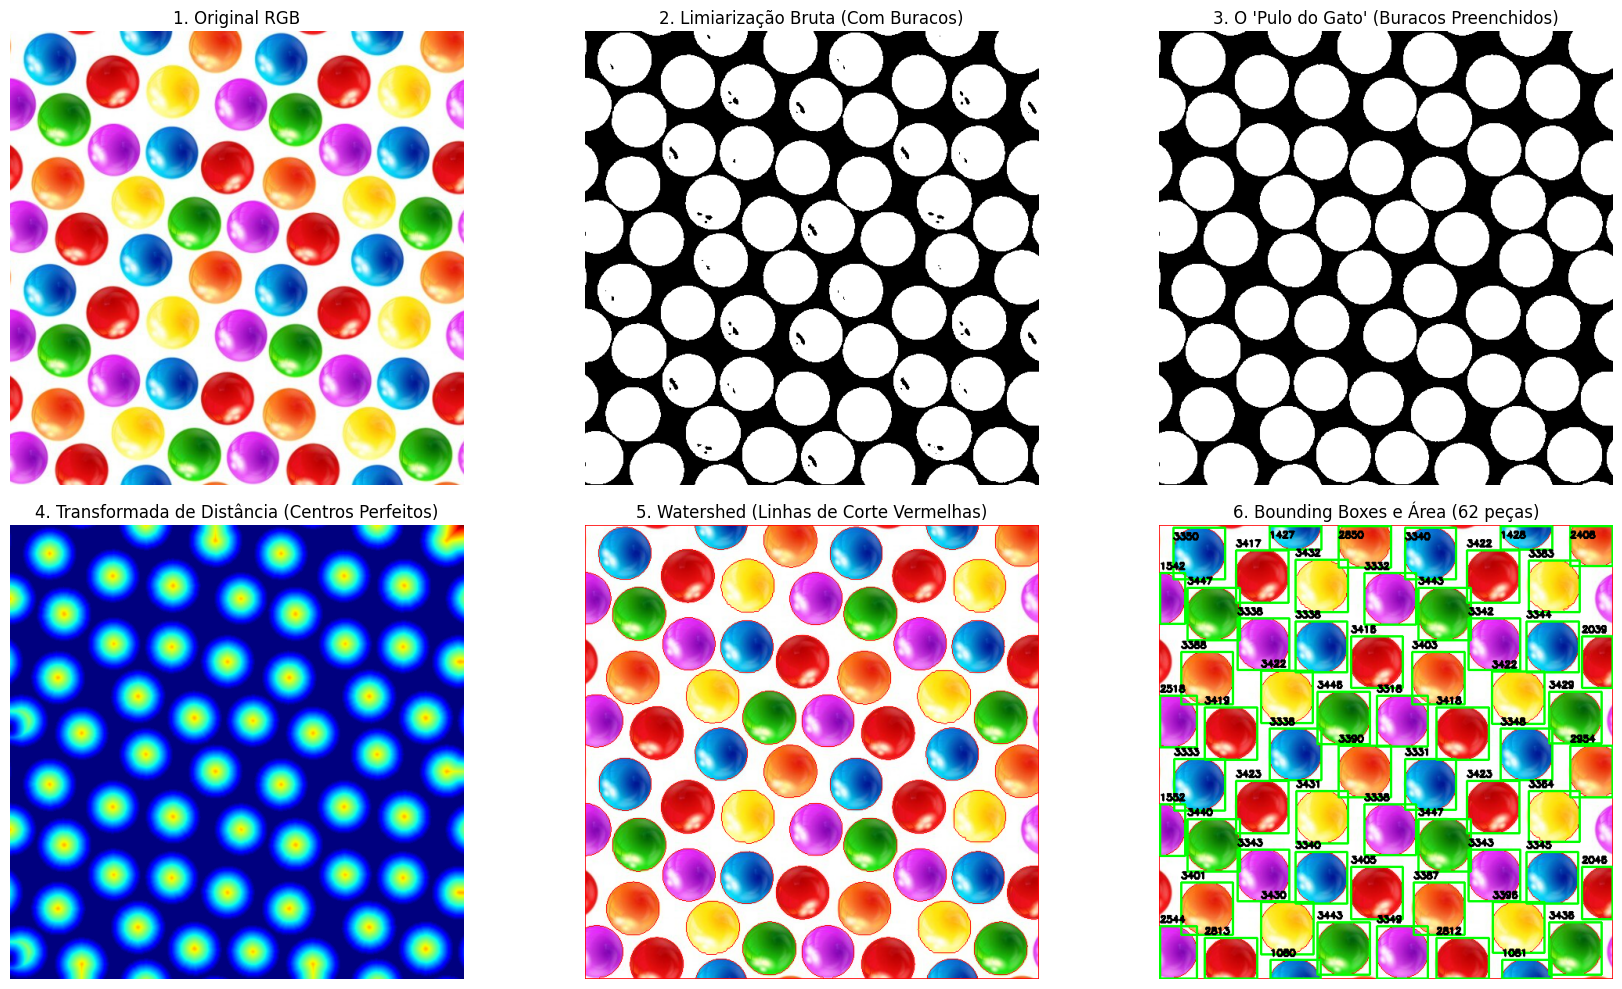

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("="*75)
print("LABORATÓRIO: TRATAMENTO AVANÇADO, WATERSHED E BOUNDING BOXES")
print("="*75)

# ==============================================================================
# 1. LEITURA DA IMAGEM E CONVERSÃO DE CORES
# ==============================================================================
nome_arquivo = "Captura de tela 2026-08-18 213330.png"

# cv2.imread: Lê a imagem do disco. Lembre-se: O OpenCV lê no formato BGR (Azul, Verde, Vermelho).
img_bgr = cv2.imread(nome_arquivo)

if img_bgr is None:
    print(f"\n[ERRO] Imagem '{nome_arquivo}' não encontrada. Faça o upload no Colab!")
else:
    # Convertendo a imagem de BGR para o padrão humano RGB para podermos plotar corretamente
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ==============================================================================
    # 2. ESPAÇO HSV E LIMIARIZAÇÃO (O PROBLEMA DO BRILHO)
    # ==============================================================================
    print("\n-> 1. Convertendo para HSV e extraindo o canal Saturação (S)...")

    # EXPLICAÇÃO: Se usarmos Escala de Cinza, o fundo branco da imagem e o reflexo
    # brilhante da peça ficarão com a mesma cor (branco). Isso vai "furar" a peça.
    # A solução é converter para HSV (Matiz, Saturação e Brilho) e focar na Saturação.
    # O fundo branco não tem cor (Saturação = 0), então ele desaparece facilmente!
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    canal_s = img_hsv[:, :, 1]

    # Threshold (Binarização): O que tiver Saturação maior que 30 vira 255 (Branco).
    # O que tiver menos que 30 vira 0 (Preto).
    _, mascara_bruta = cv2.threshold(canal_s, 30, 255, cv2.THRESH_BINARY)

    # ==============================================================================
    # 3. O 'PULO DO GATO': PREENCHENDO BURACOS CAUSADOS PELO REFLEXO
    # ==============================================================================
    print("-> 2. Corrigindo as falhas do reflexo (Preenchimento de Contornos)...")

    # EXPLICAÇÃO: Mesmo usando HSV, reflexos extremos não têm saturação e geram "buracos"
    # pretos no meio da nossa peça branca. Para consertar, vamos encontrar as linhas de
    # contorno externas de cada peça...
    contornos_iniciais, _ = cv2.findContours(mascara_bruta, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # ... e desenhar essas linhas preenchidas (cv2.FILLED) em uma tela preta limpa.
    # Isso cria silhuetas maciças e perfeitas, destruindo os buracos causados pelos reflexos!
    mascara_solida = np.zeros_like(mascara_bruta)
    cv2.drawContours(mascara_solida, contornos_iniciais, -1, 255, thickness=cv2.FILLED)

    # ==============================================================================
    # 4. TOPOGRAFIA: TRANSFORMADA DE DISTÂNCIA E CENTROS
    # ==============================================================================
    print("-> 3. Calculando os centros perfeitos das peças sólidas...")

    # EXPLICAÇÃO: Muitas peças estão coladas. Se extrairmos os contornos agora, o OpenCV
    # vai achar que duas peças coladas são um único "amendoim" gigante.
    # A Transformada de Distância (Distance Transform) calcula a distância de cada pixel
    # branco até a borda preta mais próxima. O pixel que estiver mais no centro da peça
    # receberá o maior número.
    dist_transform = cv2.distanceTransform(mascara_solida, cv2.DIST_L2, 5)
    dist_visual = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX) # Apenas para o gráfico

    # Limiarizamos a distância: Pegamos apenas os pixels que atingiram pelo menos 50%
    # do valor máximo (ou seja, o topo do morro/centro exato da peça).
    _, centros_certos = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    centros_certos = np.uint8(centros_certos)

    # ==============================================================================
    # 5. ALGORITMO WATERSHED (O DIVISOR DE ÁGUAS)
    # ==============================================================================
    print("-> 4. Executando o Watershed para separar as peças que se tocam...")

    # Dilatamos a máscara sólida para ter certeza de onde é o "Fundo" da esteira
    fundo_certo = cv2.dilate(mascara_solida, np.ones((3,3), np.uint8), iterations=2)

    # A área "Desconhecida" é justamente a borda cinzenta onde as peças se tocam
    area_desconhecida = cv2.subtract(fundo_certo, centros_certos)

    # connectedComponents: Dá um ID (um número) único para o centro de cada peça
    num_labels, marcadores = cv2.connectedComponents(centros_certos)
    marcadores = marcadores + 1 # O fundo precisa ser 1, e não 0
    marcadores[area_desconhecida == 255] = 0 # A área desconhecida vira 0 (água flui aqui)

    # Inundando a imagem com Watershed. Ele vai colocar o número '-1' onde as águas
    # de duas peças vizinhas se chocam (criando uma represa/linha de corte matemática).
    img_watershed = img_rgb.copy()
    marcadores_finais = cv2.watershed(img_watershed, marcadores)

    # Pintamos as linhas de corte (onde for -1) com a cor Vermelha RGB: [255, 0, 0]
    img_watershed[marcadores_finais == -1] = [255, 0, 0]

    # ==============================================================================
    # 6. ANÁLISE ESPACIAL: CAIXAS DELIMITADORAS E ÁREA
    # ==============================================================================
    print("-> 5. Desenhando Bounding Boxes e calculando a Área em Pixels...")
    img_resultado = img_watershed.copy()
    pecas_contadas = 0

    # EXPLICAÇÃO: Vamos rodar um loop (laço de repetição). O número 1 é o fundo.
    # Nossas peças começam a partir do ID 2 até o total de rótulos encontrados pelo Watershed.
    for label in range(2, num_labels + 1):

        # Isola apenas a peça da vez criando uma máscara vazia (preta) e acendendo ela
        mascara_peca_unica = np.zeros_like(mascara_solida)
        mascara_peca_unica[marcadores_finais == label] = 255

        # Acha o contorno DESSA peça específica (agora separada das vizinhas)
        cnts, _ = cv2.findContours(mascara_peca_unica, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if cnts:
            # Pega o maior contorno (para garantir que não estamos pegando poeira)
            c = max(cnts, key=cv2.contourArea)

            # contourArea: Calcula o tamanho da peça em pixels
            area = cv2.contourArea(c)

            # Filtro lógico: A área tem que ser maior que 200 pixels para contar como peça
            if area > 200:
                pecas_contadas += 1

                # boundingRect: Pega as coordenadas X, Y e Largura/Altura (W, H)
                x, y, w, h = cv2.boundingRect(c)

                # cv2.rectangle: Desenha o quadrado verde (0, 255, 0)
                cv2.rectangle(img_resultado, (x, y), (x+w, y+h), (0, 255, 0), 2)

                # cv2.putText: Escreve o texto com o valor da área sobre a peça
                texto = f"{int(area)}"
                pos_y = y - 5 if y - 5 > 10 else y + 15 # Impede o texto de sair da tela
                cv2.putText(img_resultado, texto, (x, pos_y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 2)

    print(f"\n[SUCESSO] Total de Esferas Perfeitas detectadas: {pecas_contadas}")

    # ==============================================================================
    # 7. RENDERIZAÇÃO DIDÁTICA (MATPLOTLIB)
    # ==============================================================================
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))

    ax[0, 0].imshow(img_rgb)
    ax[0, 0].set_title("1. Original RGB")

    ax[0, 1].imshow(mascara_bruta, cmap='gray')
    ax[0, 1].set_title("2. Limiarização Bruta (Com Buracos)")

    ax[0, 2].imshow(mascara_solida, cmap='gray')
    ax[0, 2].set_title("3. O 'Pulo do Gato' (Buracos Preenchidos)")

    ax[1, 0].imshow(dist_visual, cmap='jet') # cmap='jet' para o mapa de calor térmico
    ax[1, 0].set_title("4. Transformada de Distância (Centros Perfeitos)")

    ax[1, 1].imshow(img_watershed)
    ax[1, 1].set_title("5. Watershed (Linhas de Corte Vermelhas)")

    ax[1, 2].imshow(img_resultado)
    ax[1, 2].set_title(f"6. Bounding Boxes e Área ({pecas_contadas} peças)")

    # Esconde os eixos X e Y de todas as imagens para ficar limpo
    for a in ax.flat:
        a.axis('off')

    plt.tight_layout()
    plt.show()

PREPARAÇÃO DE DADOS PARA REDES CONVOLUCIONAIS (CNN)

-> 1. Baixando banco de imagens de exemplo...
228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
-> 2. Criando o Pipeline de Tensores (Treino e Validação)...
Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.

Categorias encontradas automaticamente: ['flower_photos']

-> 3. Construindo o Bloco de Pré-processamento Interno da CNN...

-> Renderizando o efeito do Data Augmentation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


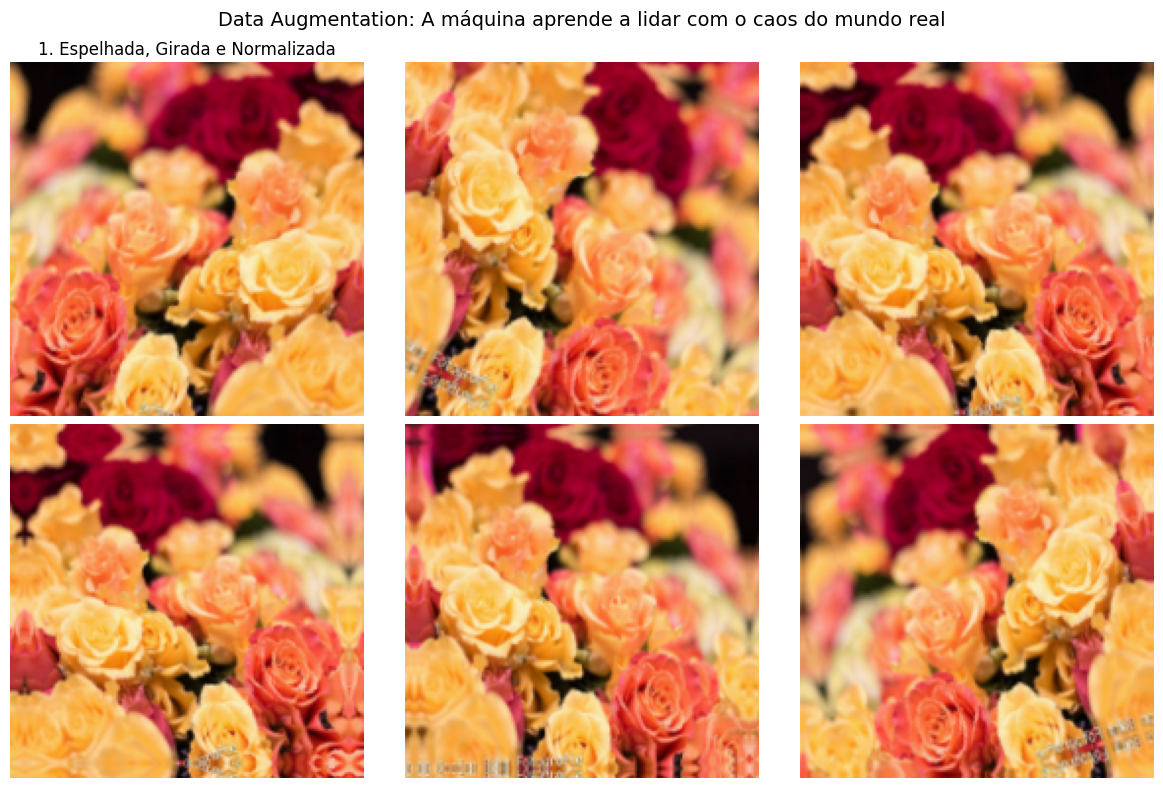


Conclusão: As imagens não sofrem filtros OpenCV.
Elas entram cruas na CNN. A variação geométrica cria robustez, e as camadas de
Convolução (que faremos na próxima aula) descobrirão as bordas sozinhas!


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt
import os

print("="*70)
print("PREPARAÇÃO DE DADOS PARA REDES CONVOLUCIONAIS (CNN)")
print("="*70)

# ==============================================================================
# 1. DOWNLOAD E ESTRUTURA DE PASTAS (O Padrão da Indústria)
# ==============================================================================
print("\n-> 1. Baixando banco de imagens de exemplo...")
# O Keras exige que as fotos estejam organizadas em pastas com o nome da classe.
# Exemplo Industrial: pasta_principal/peca_boa/ e pasta_principal/peca_defeituosa/
# Aqui usaremos um dataset público de flores simulando 5 categorias diferentes.

url_dataset = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
diretorio_base = tf.keras.utils.get_file('flower_photos', origin=url_dataset, untar=True)

# ==============================================================================
# 2. INGESTÃO OTMIZADA: image_dataset_from_directory
# ==============================================================================
print("-> 2. Criando o Pipeline de Tensores (Treino e Validação)...")
# Parâmetros vitais para a CNN
LARGURA = 180
ALTURA = 180
TAMANHO_LOTE = 32 # A GPU vai ler 32 fotos de uma vez

# O Keras lê a pasta, descobre as categorias, redimensiona as fotos e já isola 80% pro Treino
dataset_treino = tf.keras.utils.image_dataset_from_directory(
  diretorio_base,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(ALTURA, LARGURA),
  batch_size=TAMANHO_LOTE
)

# Os 20% restantes vão para a Validação (O nosso Simulado)
dataset_val = tf.keras.utils.image_dataset_from_directory(
  diretorio_base,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(ALTURA, LARGURA),
  batch_size=TAMANHO_LOTE
)

nomes_das_classes = dataset_treino.class_names
print(f"\nCategorias encontradas automaticamente: {nomes_das_classes}")

# Otimização de Memória e Processamento da GPU (Puxa os dados do HD em paralelo)
AUTOTUNE = tf.data.AUTOTUNE
dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dataset_val = dataset_val.cache().prefetch(buffer_size=AUTOTUNE)

# ==============================================================================
# 3. NORMALIZAÇÃO E AUMENTO DE DADOS (DATA AUGMENTATION)
# ==============================================================================
print("\n-> 3. Construindo o Bloco de Pré-processamento Interno da CNN...")

# Em vez de tratarmos as imagens fora, nós criamos "Camadas" que tratam a imagem
# no exato milissegundo em que ela entra na Rede Neural!
bloco_pre_processamento = Sequential([
  # 1. Normalização: Esmaga os pixels de 0 a 255 para o intervalo 0.0 a 1.0
  layers.Rescaling(1./255, input_shape=(ALTURA, LARGURA, 3)),

  # 2. Data Augmentation: Simula as variações da câmera no chão de fábrica
  layers.RandomFlip("horizontal"), # Espelha a foto aleatoriamente
  layers.RandomRotation(0.1),      # Gira a foto em até 10%
  layers.RandomZoom(0.1)           # Dá um micro-zoom para a IA não viciar no tamanho
], name="Preparacao_da_Imagem")

# ==============================================================================
# 4. DEMONSTRAÇÃO VISUAL DO AUMENTO DE DADOS
# ==============================================================================
print("\n-> Renderizando o efeito do Data Augmentation...")

# Pegando uma única foto (a primeira do primeiro lote)
for imagens, rotulos in dataset_treino.take(1):
    foto_unica = imagens[0]

# Gerando 6 variações aleatórias da mesma foto usando o nosso bloco
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Data Augmentation: A máquina aprende a lidar com o caos do mundo real", fontsize=14)

for i, a in enumerate(ax.flat):
    # Passamos a foto única pelo bloco (o training=True liga o modo aleatório)
    foto_modificada = bloco_pre_processamento(tf.expand_dims(foto_unica, 0), training=True)

    # Renderizamos a imagem (removemos a dimensão extra do lote para o Matplotlib ler)
    a.imshow(foto_modificada[0])
    a.axis("off")
    if i == 0:
        a.set_title("1. Espelhada, Girada e Normalizada")

plt.tight_layout()
plt.show()

print("\nConclusão: As imagens não sofrem filtros OpenCV.")
print("Elas entram cruas na CNN. A variação geométrica cria robustez, e as camadas de")
print("Convolução (que faremos na próxima aula) descobrirão as bordas sozinhas!")

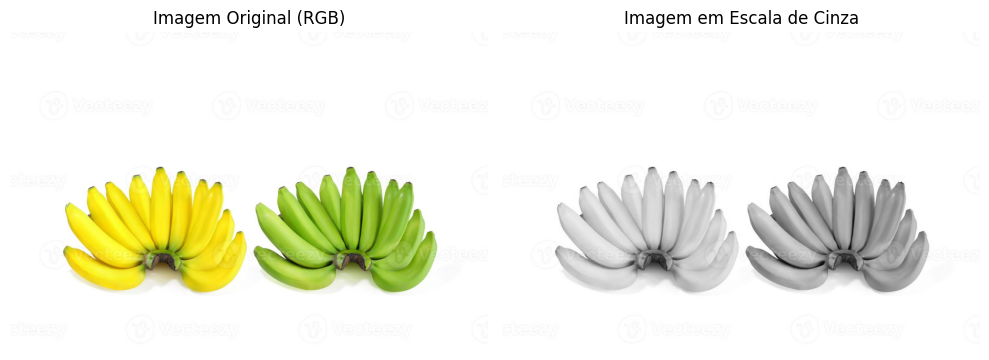

In [8]:
import cv2
import matplotlib.pyplot as plt

nome_arquivo = "11829971-banana-crua-e-banana-madura-isoladas-no-fundo-branco-com-secao-transversal-e-profundidade-de-campo-foto.jpg"

# cv2.imread: Lê a imagem do disco. Lembre-se: O OpenCV lê no formato BGR (Azul, Verde, Vermelho).
img_bgr = cv2.imread(nome_arquivo)
# Verifica se a imagem RGB já foi carregada em uma célula anterior
if 'img_rgb' in locals():
    # Converte a imagem RGB para escala de cinza
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Exibe a imagem original e a imagem em escala de cinza
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem Original (RGB)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Imagem em Escala de Cinza')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Por favor, execute a célula que carrega a imagem 'img_rgb' primeiro.")